In [1]:
from sklearn.datasets import make_circles

n_sample = 1000

X, y = make_circles(n_sample,noise=0.02,random_state=42)

In [2]:
print(f"First five be \n{X[:5]} \nand\n {y[:5]}")

First five be 
[[ 0.76026594  0.22387823]
 [-0.76722217  0.1455425 ]
 [-0.80815854  0.14894355]
 [-0.3760283   0.70320906]
 [ 0.44051035 -0.89761737]] 
and
 [1 1 1 1 0]


In [3]:
import pandas as pd
circles = pd.DataFrame({'X1': X[:,0],'X2': X[:,1],'labels':y})
circles.head(10)

,X1,X2,labels
0,0.760266,0.223878,1
1,-0.767222,0.145542,1
2,-0.808159,0.148944,1
3,-0.376028,0.703209,1
4,0.440510,-0.897617,0
5,-0.484527,0.660633,1
6,-0.012450,0.802211,1
7,0.777458,0.141876,1
8,-0.166138,-0.790265,1
9,-0.126921,1.011160,0


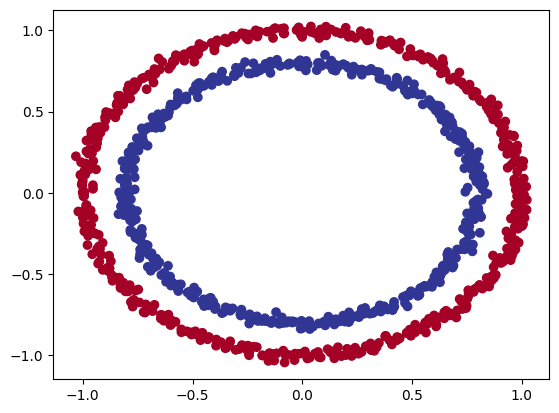

In [4]:
import matplotlib.pyplot as plt

plt.scatter(x=X[:,0],y=X[:,1],c=y,cmap=plt.cm.RdYlBu)

In [5]:
X.shape, y.shape

((1000, 2), (1000,))

In [6]:
import torch
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()

X[:5], y[:5]

(tensor([[ 0.7603,  0.2239],
         [-0.7672,  0.1455],
         [-0.8082,  0.1489],
         [-0.3760,  0.7032],
         [ 0.4405, -0.8976]]),
 tensor([1., 1., 1., 1., 0.]))

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [8]:
import torch
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [9]:
class CircleModeV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2,out_features=10)
        self.hidden_layer = nn.Linear(in_features=10,out_features=10)
        self.layer2 = nn.Linear(in_features=10,out_features=1)

    def forward(self,x):
        return self.layer2(self.hidden_layer(self.layer1(x)))

model = CircleModeV0().to(device)
model

CircleModeV0(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (hidden_layer): Linear(in_features=10, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=1, bias=True)
)

In [10]:
untrained_preds = model(X_test)
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[ 0.0510],
        [ 0.0441],
        [-0.0417],
        [ 0.0770],
        [-0.2263],
        [-0.2295],
        [-0.1108],
        [-0.1764],
        [-0.0298],
        [ 0.0378]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [26]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model.parameters(),lr=0.1)

In [12]:
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct/len(y_pred))*100
    return acc

In [13]:
y_logits = model(X_test)[:5]
y_logits

tensor([[ 0.0510],
        [ 0.0441],
        [-0.0417],
        [ 0.0770],
        [-0.2263]], grad_fn=<SliceBackward0>)

In [14]:
y_preds_p = torch.sigmoid(y_logits)
y_preds_p

tensor([[0.5128],
        [0.5110],
        [0.4896],
        [0.5192],
        [0.4437]], grad_fn=<SigmoidBackward0>)

In [15]:
y_preds = torch.round(y_preds_p)

y_preds_label = torch.round(torch.sigmoid(model(X_test))[:5])

print(torch.eq(y_preds.squeeze(), y_preds_label.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([1., 1., 0., 1., 0.], grad_fn=<SqueezeBackward0>)

In [16]:
torch.manual_seed(42)

epochs = 1000

for epoch in range(epochs):
    model.train()

    y_logits = model(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits,y_train)
    accuracy = accuracy_fn(y_true=y_train,y_pred=y_preds)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true=y_test,y_pred=test_preds)

    if epoch%10 == 0:
         print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {accuracy:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69527, Accuracy: 48.25% | Test loss: 0.69657, Test acc: 44.50%
Epoch: 10 | Loss: 0.69394, Accuracy: 49.25% | Test loss: 0.69549, Test acc: 52.50%
Epoch: 20 | Loss: 0.69360, Accuracy: 49.88% | Test loss: 0.69515, Test acc: 51.00%
Epoch: 30 | Loss: 0.69343, Accuracy: 50.75% | Test loss: 0.69495, Test acc: 49.50%
Epoch: 40 | Loss: 0.69331, Accuracy: 50.62% | Test loss: 0.69481, Test acc: 50.50%
Epoch: 50 | Loss: 0.69323, Accuracy: 50.25% | Test loss: 0.69471, Test acc: 51.50%
Epoch: 60 | Loss: 0.69317, Accuracy: 50.62% | Test loss: 0.69463, Test acc: 49.00%
Epoch: 70 | Loss: 0.69312, Accuracy: 50.88% | Test loss: 0.69457, Test acc: 48.00%
Epoch: 80 | Loss: 0.69309, Accuracy: 51.00% | Test loss: 0.69453, Test acc: 48.50%
Epoch: 90 | Loss: 0.69306, Accuracy: 50.25% | Test loss: 0.69451, Test acc: 47.50%
Epoch: 100 | Loss: 0.69304, Accuracy: 51.00% | Test loss: 0.69449, Test acc: 49.00%
Epoch: 110 | Loss: 0.69303, Accuracy: 51.12% | Test loss: 0.69448, Test acc: 46.50%
Epo

In [3]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


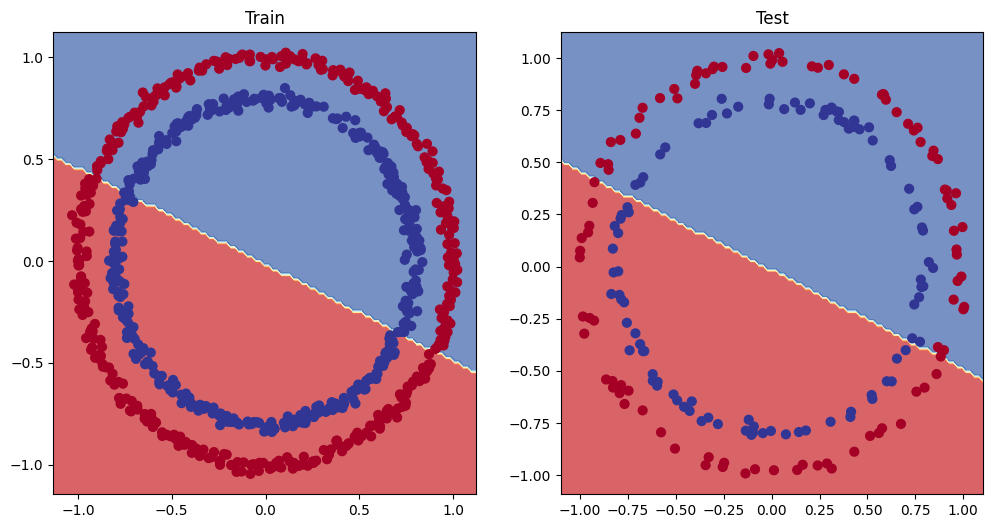

In [18]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model,X_test,y_test)

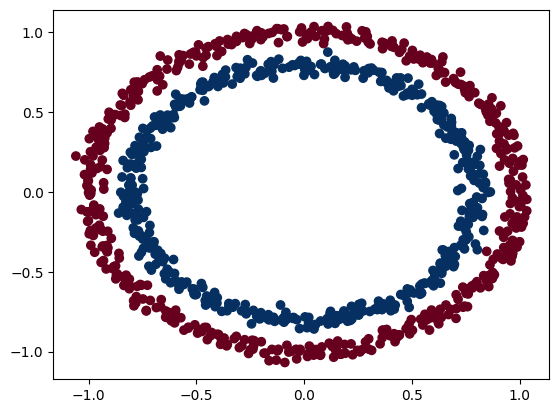

In [19]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples=1000,noise=0.03,random_state=42)

plt.scatter(X[:,0], X[:,1],c=y,cmap=plt.cm.RdBu)

In [20]:
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [21]:
from torch import nn

class CircleModule2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer3 = nn.Linear(in_features = 10, out_features = 1)
        self.relu = nn.ReLU()

    def forward(self,x):
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

model1 = CircleModule2()
print(model1)

CircleModule2(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [29]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model1.parameters(),lr=0.1)

In [33]:
torch.manual_seed(42)

epochs = 1000

for epoch in range(epochs):
    #model1.train()

    y_logits = model1(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)

    acc = accuracy_fn(y_true=y_train,y_pred=y_preds)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model1.eval()
    with torch.inference_mode():
        test_logits = model1(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true=y_test,y_pred=test_preds)
    
    if epoch%10==0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69114, Accuracy: 52.88% | Test Loss: 0.69101, Test Accuracy: 52.50%
Epoch: 10 | Loss: 0.69101, Accuracy: 52.88% | Test Loss: 0.69087, Test Accuracy: 53.50%
Epoch: 20 | Loss: 0.69089, Accuracy: 53.12% | Test Loss: 0.69072, Test Accuracy: 54.00%
Epoch: 30 | Loss: 0.69075, Accuracy: 53.00% | Test Loss: 0.69057, Test Accuracy: 54.50%
Epoch: 40 | Loss: 0.69062, Accuracy: 53.00% | Test Loss: 0.69041, Test Accuracy: 55.00%
Epoch: 50 | Loss: 0.69049, Accuracy: 52.88% | Test Loss: 0.69025, Test Accuracy: 55.00%
Epoch: 60 | Loss: 0.69035, Accuracy: 53.00% | Test Loss: 0.69008, Test Accuracy: 55.00%
Epoch: 70 | Loss: 0.69021, Accuracy: 53.12% | Test Loss: 0.68992, Test Accuracy: 55.00%
Epoch: 80 | Loss: 0.69006, Accuracy: 52.75% | Test Loss: 0.68974, Test Accuracy: 55.00%
Epoch: 90 | Loss: 0.68991, Accuracy: 53.25% | Test Loss: 0.68956, Test Accuracy: 55.00%
Epoch: 100 | Loss: 0.68976, Accuracy: 53.25% | Test Loss: 0.68938, Test Accuracy: 55.50%
Epoch: 110 | Loss: 0.68960, Accu

In [47]:
model1.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model1(X_test))).squeeze()

y_preds[:10], y[:10]

(tensor([1., 1., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

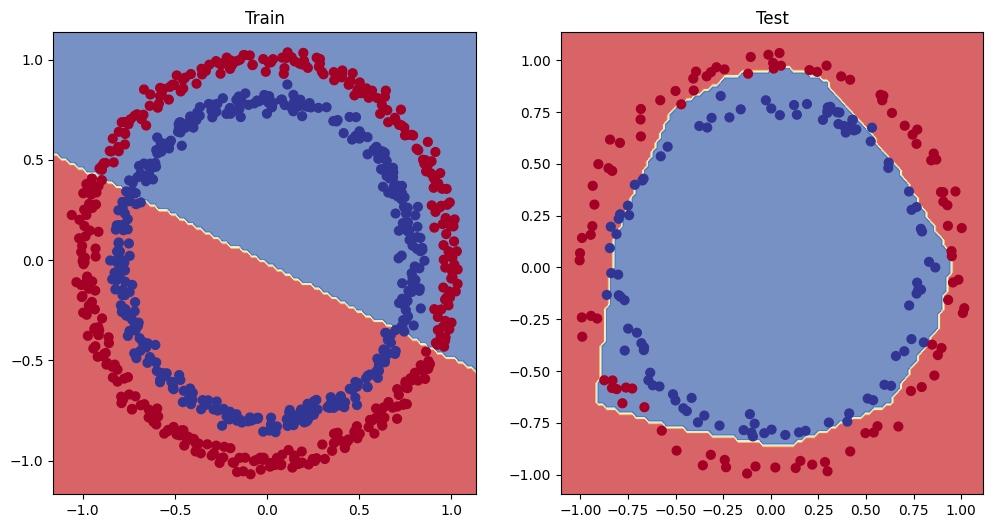

In [35]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model1,X_test,y_test)

In [37]:
A = torch.arange(-10,10,1,dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

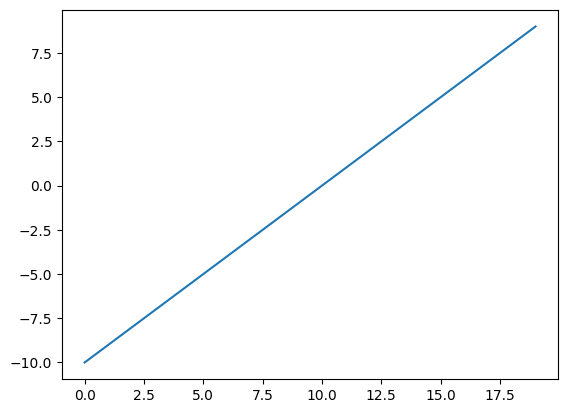

In [40]:
plt.plot(A)

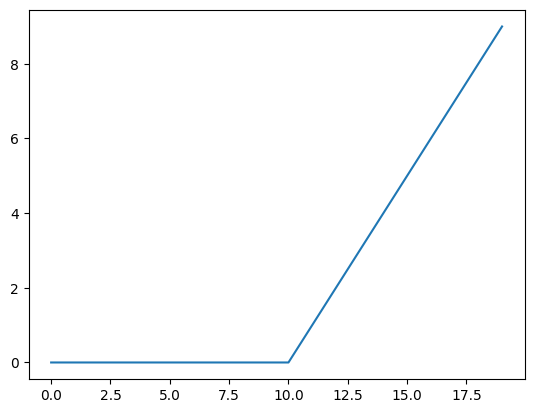

In [42]:
def relu(x):
    return torch.maximum(torch.tensor(0),x)

relu(A)

plt.plot(relu(A))

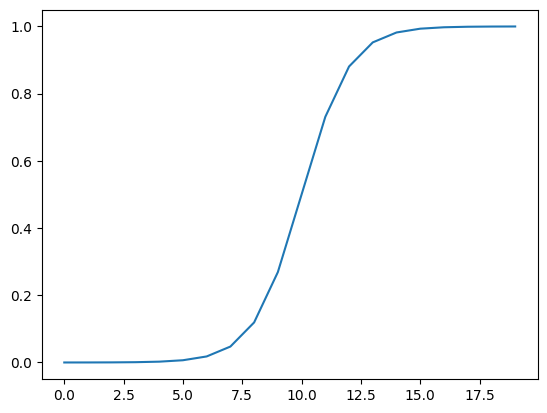

In [43]:
def sigmoid(x):
    return 1/(1+torch.exp(-x))

sigmoid(A)

plt.plot(sigmoid(A))